<center><h1>Numerical approximation</h1></center>
<center><h3>Trigonometric least squares fitting</h3></center>

- - - - - - - - - - - - - - -

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

- - - - - - - - - - - - - - -

The voltage output $y$ from a microphone is sampled at equally-spaced times $t \in [0, \space T]$ to produce the data $(t_{j}, \space y_{j})$, $j = 0, \dots, 2m - 1$, where $m = 50$. After a change of variable $x = -\pi + 2\pi t/T \in [-\pi, \space \pi]$, we obtain the data $(x_{j}, \space y_{j})$ as shown on the left, where $x_{j} = -\pi + j\pi /m$.

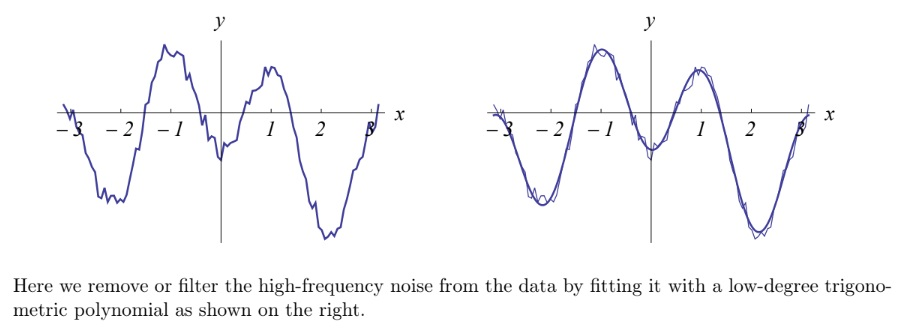

In [2]:
Image('frequency.jpg')

Compute the coefficients of the <b>least-squares trigonometric polynomial</b> $S_{n}(x)$ for the given data $(x_{j}, \space y_{j})$, $j = 0, \dots, 2m - 1$, and the degree $2 \leq n \leq m$. Also compute the associated fitting error $E_{n} = \sum_{j}[y_{j} - S_{n}(x_{j})]^{2}$.

Find the <b>least-squares trigonometric polynomials</b> of degrees $n = 2, 3, 4$ for the data provided. For each $n$, report the coefficients of $S_{n}(x)$ and the fitting error $E_{n}$. As before, since $E_{n}$ generally decreases with $n$, an appropriate fitting degree can be identified by increasing $n$ from its initial value until $|E_{n} - E_{n-1}|/E_{n-1} < 5\%$. Use this method to find an appropriate degree, and make a plot of $S_{n}(x)$, $x \in [-\pi, \space \pi]$ for this degree. Does $S_{n}(x)$ look like a filtered version of the noisy signal
shown above? The number $\gamma = 1 - \frac{n}{m} \in [0, 1]$ represents a compression ratio: a given set of $2m$ data points can be converted into a smaller set of $2n$ coefficients which can be used to approximately re-create the data when desired; $\gamma = 0$ means no compression, $\gamma = 1$ means complete compression. What is the compression ratio $\gamma$ for each fitting degree found?

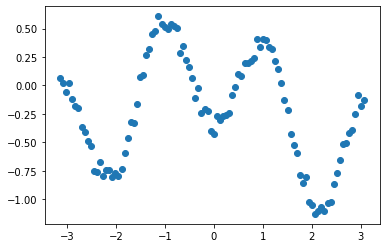

In [3]:
x = np.array([-3.142, -3.079, -3.016, -2.953, -2.89, -2.827, -2.765, -2.702, -2.639, -2.576,
              -2.513, -2.45, -2.388, -2.325, -2.262, -2.199, -2.136, -2.073, -2.011, -1.948,
              -1.885, -1.822, -1.759, -1.696, -1.634, -1.571, -1.508, -1.445, -1.382, -1.319,
              -1.257, -1.194, -1.131, -1.068, -1.005, -0.9425, -0.8796, -0.8168, -0.754, -0.6912,
              -0.6283, -0.5655, -0.5027, -0.4398, -0.377, -0.3142, -0.2513, -0.1885, -0.1257, -0.06283,
              0, 0.06283, 0.1257, 0.1885, 0.2513, 0.3142, 0.377, 0.4398, 0.5027, 0.5655,
              0.6283, 0.6912, 0.754, 0.8168, 0.8796, 0.9425, 1.005, 1.068, 1.131, 1.194,
              1.257, 1.319, 1.382, 1.445, 1.508, 1.571, 1.634, 1.696, 1.759, 1.822,
              1.885, 1.948, 2.011, 2.073, 2.136, 2.199, 2.262, 2.325, 2.388, 2.45,
              2.513, 2.576, 2.639, 2.702, 2.765, 2.827, 2.89, 2.953, 3.016, 3.079])
y = np.array([0.06832, 0.01777, -0.05477, 0.02502, -0.1207, -0.1809, -0.1998, -0.3606, -0.4097, -0.4855,
              -0.5312, -0.7495, -0.7636, -0.6707, -0.7979, -0.7424, -0.7411, -0.8049, -0.7721, -0.7963,
              -0.7339, -0.5963, -0.4647, -0.3208, -0.3302, -0.1628, 0.07076, 0.09157, 0.2684, 0.3238,
              0.4527, 0.4753, 0.6081, 0.5421, 0.5119, 0.5, 0.5431, 0.5229, 0.5067, 0.2878,
              0.343, 0.2233, 0.16, 0.06335, -0.1138, -0.02086, -0.2439, -0.2109, -0.2254, -0.3954,
              -0.4238, -0.2723, -0.3013, -0.2711, -0.2593, -0.2457, -0.08467, -0.009232, 0.09676, 0.07933,
              0.1937, 0.1985, 0.2164, 0.2449, 0.4075, 0.3338, 0.4063, 0.3984, 0.3351, 0.3222,
              0.2109, 0.1415, 0.01951, -0.1317, -0.2194, -0.4258, -0.5249, -0.5939, -0.7906, -0.8522,
              -0.8046, -1.021, -1.048, -1.128, -1.106, -1.066, -1.102, -1.036, -1.023, -0.8649,
              -0.7706, -0.6505, -0.516, -0.5012, -0.4192, -0.3945, -0.2484, -0.08365, -0.1774, -0.1283])

plt.scatter(x, y)
plt.show()

In [4]:
def ls_trigonometric(n, m):
    threshold_error = 0
    prev_error = 0

    while(True):
        '''We initialise A and B as arrays of zeros with different sizes depending on the trigonometic function.'''
        A = [0] * (n + 1)
        B = [0] * (n - 1)
        
        '''Calculating coefficients for the cosine function.'''
        for k in range(n + 1):
            sum = 0
            for j in range(2 * m):
                sum += y[j] * np.cos(k * x[j])
            A[k] = 1/m * sum
            sum = 0

        '''Calculating coefficients for the sine function.'''
        for k in range(n - 1):
            sum = 0
            for j in range(2 * m):
                sum += y[j] * np.sin((k + 1) * x[j])
            B[k] = 1/m * sum
            sum = 0

        '''Summation of sine and cosine function values with coefficients to generate the fitting error.'''
        error = 0
        fitting_error = 0
        for j in range(2 * m):
            fitting_error = A[0]/2 + A[n] * np.cos(n * x[j])
            for k in range(1, n):
                fitting_error += A[k] * np.cos(k * x[j]) + B[k - 1] * np.sin(k * x[j])
            error += (y[j] - fitting_error)**2
            fitting_error = 0
        n += 1
        
        if (threshold_error > 0.05 and n < m):
            continue
        else:
            return A, B, error

if __name__ == "__main__":
    n = 2
    m = 50
    A, B, error = ls_trigonometric(n, m)
    
    print(f'Number of data points 2m: {2*m}')
    print(f'The trigonometric polynomial degree: {n}')
    print('Cosine co-efficients (a_0, ..., a_n):')
    print(A)
    print('Sine co-efficients (b_1, ..., b_n-1):')
    print(B)
    print(f'Fitting error: {error}')
    print(f'Compression ratio: {1 - (n + 1)/m}')

Number of data points 2m: 100
The trigonometric polynomial degree: 2
Cosine co-efficients (a_0, ..., a_n):
[-0.44570183999999985, 0.36963858921361814, 0.03196160683565699]
Sine co-efficients (b_1, ..., b_n-1):
[-0.1351240402745351]
Fitting error: 14.279844515363736
Compression ratio: 0.94


In [5]:
n = 3
m = 50
A, B, error = ls_trigonometric(n, m)
    
print(f'Number of data points 2m: {2*m}')
print(f'The trigonometric polynomial degree: {n}')
print('Cosine co-efficients (a_0, ..., a_n):')
print(A)
print('Sine co-efficients (b_1, ..., b_n-1):')
print(B)
print(f'Fitting error: {error}')
print(f'Compression ratio: {1 - (n + 1)/m}')

Number of data points 2m: 100
The trigonometric polynomial degree: 3
Cosine co-efficients (a_0, ..., a_n):
[-0.44570183999999985, 0.36963858921361814, 0.03196160683565699, -0.5282055373438044]
Sine co-efficients (b_1, ..., b_n-1):
[-0.1351240402745351, 0.025439086259360973]
Fitting error: 0.2974867112413631
Compression ratio: 0.92


In [6]:
n = 4
m = 50
A, B, error = ls_trigonometric(n, m)
    
print(f'Number of data points 2m: {2*m}')
print(f'The trigonometric polynomial degree: {n}')
print('Cosine co-efficients (a_0, ..., a_n):')
print(A)
print('Sine co-efficients (b_1, ..., b_n-1):')
print(B)
print(f'Fitting error: {error}')
print(f'Compression ratio: {1 - (n + 1)/m}')

Number of data points 2m: 100
The trigonometric polynomial degree: 4
Cosine co-efficients (a_0, ..., a_n):
[-0.44570183999999985, 0.36963858921361814, 0.03196160683565699, -0.5282055373438044, 0.011172465318157502]
Sine co-efficients (b_1, ..., b_n-1):
[-0.1351240402745351, 0.025439086259360973, -0.015270238723629141]
Fitting error: 0.2795677432899212
Compression ratio: 0.9


For plotting $S_{n}(x)$ for each degree, define
<center>$S_{n}(x) = \dfrac{a_{0}}{2} + \displaystyle\sum_{k = 1}^{n} (a_{k}cos(kx) + b_{k}sin(kx))$</center>
as the form of <b>least squares trigonometric approximation</b>.

#### degree: n = 2

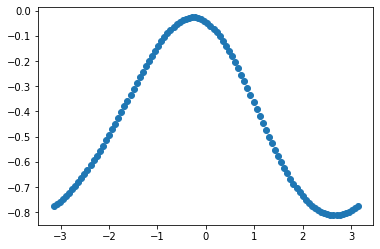

In [7]:
def ls_approx(x):
    return (- 0.4416678195943198 * np.cos(0*x)
            + 0.36636520131580214 * np.cos(1*x)
            + 0.03121899277298045 * np.cos(2*x)
            - 0.1337727998717897 * np.sin(1*x)
           )

x = np.linspace(-np.pi, np.pi, 100)
y = ls_approx(x)

plt.scatter(x, y)
plt.show()

#### degree: n = 3

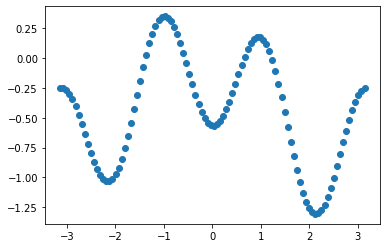

In [8]:
def ls_approx(x):
    return (- 0.4416678195943198 * np.cos(0*x)
            + 0.36636520131580214 * np.cos(1*x)
            + 0.03121899277298045 * np.cos(2*x)
            - 0.5225004839760462 * np.cos(3*x)
            - 0.1337727998717897 * np.sin(1*x)
            + 0.025184695396767345 * np.sin(2*x)
           )

x = np.linspace(-np.pi, np.pi, 100)
y = ls_approx(x)

plt.scatter(x, y)
plt.show()

#### degree: n = 4

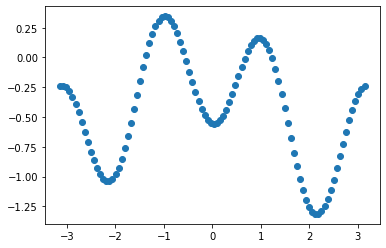

In [9]:
def ls_approx(x):
    return (- 0.4416678195943198 * np.cos(0*x)
            + 0.36636520131580214 * np.cos(1*x)
            + 0.03121899277298045 * np.cos(2*x)
            - 0.5225004839760462 * np.cos(3*x)
            + 0.010637742670656052 * np.cos(4*x)
            - 0.1337727998717897 * np.sin(1*x)
            + 0.025184695396767345 * np.sin(2*x)
            - 0.015117536336392857 * np.sin(3*x)
           )

x = np.linspace(-np.pi, np.pi, 100)
y = ls_approx(x)

plt.scatter(x, y)
plt.show()

This looks much like the original graph above!

## Further readings:
Reading material:<br>
https://www.amazon.com/Numerical-Analysis-Richard-L-Burden/dp/1305253663/

## Useful links:
Quick definition:<br>
https://sites.millersville.edu/rbuchanan/math375/TrigPoly.pdf